In [1]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
import tqdm
%matplotlib inline
from IPython.display import clear_output
from typing import List, Tuple, Optional
import matplotlib.ticker as mticker

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_token_folder = "drive/MyDrive/mestrado_final_files/models/NGramModel_ExtraInfo/"
# models_token_metrics_folder = "drive/MyDrive/mestrado_final_files/metrics_models/NGramModel_ExtraInfo/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo\\"

#models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
def get_vectorized_murphy(y_true_multiclasse, y_prob_matriz, top_n=600, n_bins=10):
    """
    Calcula as métricas de Murphy de forma vetorizada, corrigindo o
    shape de arrays dinâmicos e espelhando a discretização exata do pd.cut.
    """
    N_amostras = len(y_true_multiclasse)
    if N_amostras == 0:
        return pd.DataFrame()

    # 1. Identificar Top Tokens presentes estritamente neste slice
    tokens, counts = np.unique(y_true_multiclasse, return_counts=True)
    sort_idx = np.argsort(-counts)

    top_tokens_ids = tokens[sort_idx][:top_n]
    top_counts = counts[sort_idx][:top_n]

    # A CORREÇÃO CRÍTICA DO SHAPE:
    actual_n = len(top_tokens_ids)

    # 2. Isolar matrizes para os tokens filtrados
    P = y_prob_matriz[:, top_tokens_ids]
    Y = (y_true_multiclasse[:, None] == top_tokens_ids).astype(float)

    # 3. Taxas Base e Incerteza
    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    # 4. Discretização exata equivalente ao pd.cut(include_lowest=True)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    # digitize com right=True aloca valores <= à borda direita do bin
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    # Vetores dimensionados corretamente para o slice atual
    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = (bins == b) # booleano (N_amostras, actual_n)
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        # np.where é mais seguro e direto que multiplicar float por bool
        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        true_fraction = np.zeros(actual_n)
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras
        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid])**2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid])**2

    brier_score = reliability - resolution + uncertainty

    return pd.DataFrame({
        'token_id': top_tokens_ids,
        'frequencia': top_counts,
        'brier_score_multinomial': brier_score,
        'reliability_erro': reliability,
        'resolution_poder': resolution,
        'uncertainty_caos': uncertainty
    })

def get_vectorized_murphy_all_classes(y_true_multiclasse, y_prob_matriz, classes=None, n_bins=10):
    """
    Calcula a decomposição de Murphy considerando todas as classes possíveis.
    Isso evita perder reliability de classes não observadas no y_true do grupo,
    mas que receberam probabilidade positiva do modelo.
    """
    N_amostras = len(y_true_multiclasse)

    if N_amostras == 0:
        return pd.DataFrame()

    if classes is None:
        classes = np.arange(y_prob_matriz.shape[1])

    classes = np.asarray(classes)

    P = y_prob_matriz[:, classes]
    Y = (y_true_multiclasse[:, None] == classes).astype(float)

    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    actual_n = len(classes)

    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = bins == b
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        true_fraction = np.zeros(actual_n)

        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras

        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid]) ** 2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid]) ** 2

    brier_decomp = reliability - resolution + uncertainty

    frequencia = Y.sum(axis=0).astype(int)

    return pd.DataFrame({
        "token_id": classes,
        "frequencia": frequencia,
        "brier_score_multinomial": brier_decomp,
        "reliability_erro": reliability,
        "resolution_poder": resolution,
        "uncertainty_caos": uncertainty
    })

In [4]:
with open(data_folder + 'data_time_features.pkl', 'rb') as f:
    df_time_features = pickle.load(f)

In [3]:
%run 01_functions_training.ipynb
#%run drive/MyDrive/mestrado_final_files/notebooks/01_functions_training.ipynb

In [6]:
with open(data_folder + 'dict_set_covariables.pkl', 'rb') as f:
    dict_set_covariables = pickle.load(f)

In [4]:
list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_seasondata" in item and ".pth" in item]

In [5]:
VOCAB_SIZE = 601
TIME_SIZE = 301

In [9]:
def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

def multiclass_cross_entropy(y_true, y_prob, eps=1e-15):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(np.log(y_prob[np.arange(len(y_true)), y_true]))

def process_group(idx, dev_y, all_probs, classes = None, get_bs_global = False, get_ce = False, get_mae = False):
    y_true_sub = dev_y[idx]
    y_prob_sub = all_probs[idx]

    if classes is None:
        classes = np.arange(y_prob_sub.shape[1])

    df_res = get_vectorized_murphy_all_classes(y_true_multiclasse=y_true_sub, y_prob_matriz = y_prob_sub, classes = classes, n_bins = 10)

    if get_bs_global:
        bs_global = multiclass_brier_score(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["brier_score_multinomial"] = bs_global

    if get_ce:
        ce_global = multiclass_cross_entropy(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["cross_entropy"] = ce_global

    if get_mae:
        expected_output = y_prob_sub @ np.arange(y_prob_sub.shape[1])
        mae_global = np.mean(np.abs(y_true_sub - expected_output))
        df_res["mae"] = mae_global

    return df_res

def multiclass_brier_score(y_true, y_prob):
    """
    Calcula o Brier Score Global para classificação multiclasse.
    
    y_true: array 1D com os índices reais dos tokens, shape (N,)
    y_prob: array 2D com as probabilidades preditas (softmax), shape (N, C)
    """
    N_amostras, n_classes = y_prob.shape
    
    # Cria a representação one-hot dos alvos (0.0 para erro, 1.0 para acerto)
    y_true_one_hot = np.zeros_like(y_prob, dtype=float)
    y_true_one_hot[np.arange(N_amostras), y_true] = 1.0
    
    # Calcula o erro quadrático, soma por classe e tira a média por amostra
    brier_score = np.mean(np.sum((y_prob - y_true_one_hot)**2, axis=1))
    
    return brier_score    

In [10]:
def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"


### Arquitetura B

In [11]:
list_decomposition_time = []
list_decomposition_dif = []
list_decomposition_time_dif = []
list_decomposition_season = []

group_variables1 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables2 = ["cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables3 = ["period", "cat_time", "cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables4 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_seasondata" in item and ".pth" in item and str_season in item]

    # 1. PREPARAÇÃO DOS DADOS DA TEMPORADA (FORA DO LOOP DE MODELOS)
    df_ = df_time_features.query("season == @season").query("season_split == 'dev'")

    # Processamento temporal feito uma única vez por temporada
    df_ = (df_
           .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))
           .pipe(get_match_splits, num_secs = 200))\
    .assign(cat_time = lambda df: df["cat_time"].astype("str"))\
    .assign(cat_dif = lambda df: df["token_state"] % 9)

    # Conversão eficiente de memória
    dev_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
    dev_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    dev_y = df_["target_time"].values
    dev_mask = torch.tensor(build_logit_mask_spent_time_models(df_), dtype = torch.bool, device = device)

    print(season)
    for model_filename in tqdm.tqdm(list_models):

        CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
        EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
        variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
        numerical_input_size = len(dict_set_covariables['index'][variables_config])
        num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
        num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
        dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
        layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

        index_covariables = dict_set_covariables["index"][variables_config]

        time_model = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE, 
                                    embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = numerical_input_size,
                                    num_hidden_neurons = num_hidden_neurons, num_layers = num_layers, 
                                    activation_function = nn.GELU, dropout_rate = dropout_rate, use_layer_norm = layer_norm)
    
        time_model.load_state_dict(torch.load(models_time_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
        time_model.eval()

        # 2. INFERÊNCIA
        with torch.no_grad():
            # Ajuste condicional para modelos que requerem variáveis numéricas
            output_model = time_model(dev_tkn[:, -CONTEXT_SIZE:], dev_num[:, index_covariables])

            output_model = output_model.masked_fill(dev_mask, -1e9)        
            all_probs = torch.softmax(output_model, dim = 1).cpu().numpy()

        # 3. EXTRAÇÃO POR TEMPO
        results_time = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            results_time.append(res_df)

        df_decomposition_by_time = pd.concat(results_time, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time = df_decomposition_by_time\
        .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time.append(df_resultados_time)

        results_dif = []
        for name, group_idx in df_.groupby(["season_split", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["cat_dif"] = name[1]
            results_dif.append(res_df)

        df_decomposition_by_dif = pd.concat(results_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_dif = df_decomposition_by_dif\
        .groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_dif[group_variables2 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_dif.append(df_resultados_dif)

        # 3. EXTRAÇÃO POR TIME E DIF
        results_time_dif = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            res_df["cat_dif"] = name[3]
            results_time_dif.append(res_df)

        df_decomposition_by_time_dif = pd.concat(results_time_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time_dif = df_decomposition_by_time_dif\
        .groupby(group_variables3 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time_dif[group_variables3 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time_dif.append(df_resultados_time_dif)

        # 4. EXTRAÇÃO POR SPLIT
        results_split = []
        for name, group_idx in df_.groupby(["season_split"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
            res_df["season_split"] = name
            results_split.append(res_df)

        df_decomposition_by_split = pd.concat(results_split, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_split = df_decomposition_by_split\
        .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_split[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_season.append(df_resultados_split)


2018-19


100%|██████████| 32/32 [05:21<00:00, 10.05s/it]


2019-20


100%|██████████| 32/32 [04:41<00:00,  8.79s/it]


2020-21


100%|██████████| 32/32 [04:14<00:00,  7.96s/it]


2021-22


100%|██████████| 32/32 [05:12<00:00,  9.76s/it]


2022-23


100%|██████████| 32/32 [05:25<00:00, 10.18s/it]


In [13]:
df_murphy_decomposition_by_time = pd.concat(list_decomposition_time, ignore_index = True)
df_murphy_decomposition_by_time.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TIME_MODEL.parquet", index = False, compression = "zstd")

In [14]:
df_murphy_decomposition_by_dif = pd.concat(list_decomposition_dif, ignore_index = True)
df_murphy_decomposition_by_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_dif_TIME_MODEL.parquet", index = False, compression = "zstd")

In [15]:
df_murphy_decomposition_by_time_dif = pd.concat(list_decomposition_time_dif, ignore_index = True)
df_murphy_decomposition_by_time_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_dif_TIME_MODEL.parquet", index = False, compression = "zstd")

In [16]:
df_murphy_decomposition_by_season_split = pd.concat(list_decomposition_season, ignore_index = True)
df_murphy_decomposition_by_season_split.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TIME_MODEL.parquet", index = False, compression = "zstd")


In [6]:
list_num_parametros = []
for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_seasondata" in item and ".pkl" in item and str_season in item]

    for file in tqdm.tqdm(list_models):
        with open(models_time_folder + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros.append((file.replace("results_", ""), resultados_modelo["num_parameters"]))

        

  0%|          | 0/32 [00:00<?, ?it/s]

 66%|██████▌   | 21/32 [00:15<00:08,  1.35it/s]


KeyboardInterrupt: 

In [15]:
df_parameters = pd.DataFrame(list_num_parametros, columns = ["modelname", "num_parameters"])

In [16]:
df_parameters\
.assign(seasondata = lambda df: df["modelname"].str.split("_").str[1].str.replace("seasondata", "").astype("int"))\
.assign(context_size = lambda df: df["modelname"].str.split("_").str[2].str.replace("context", "").astype("int"))\
.assign(embedding_layer_size = lambda df: df["modelname"].str.split("_").str[3].str.replace("embedding", "").astype("int"))\
.assign(num_layers = lambda df: df["modelname"].str.split("_").str[4].str.replace("numlayers", "").astype("int"))\
.assign(num_hidden_neurons = lambda df: df["modelname"].str.split("_").str[5].str.replace("numneurons", "").astype("int"))\
.assign(dropout_rate = lambda df: df["modelname"].str.split("_").str[6].str.replace("dropout", "").replace("no", 0).astype("int") / 10)\
.assign(layer_norm = lambda df: df["modelname"].str.split("_").str[7].str.replace("layernorm", ""))\
.assign(set_covariables = lambda df: df["modelname"].str.split("_").str[8].str.replace("setcovariables", "").replace("\.pkl", "", regex = True).astype("int"))\
.drop(columns = "modelname")\
.sort_values("num_parameters")\
.drop_duplicates(["context_size", "embedding_layer_size", "num_layers", "num_hidden_neurons", "layer_norm", "set_covariables"])\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "set_covariables"], columns = ["num_layers", "layer_norm"], values = "num_parameters", aggfunc= lambda x: x)\
.reset_index()

num_layers context_size embedding_layer_size num_hidden_neurons  \
layer_norm                                                        
0                     5                   32                 50   
1                     5                   32                 50   
2                     5                   64                 50   
3                     5                   64                 50   

num_layers set_covariables      3             5         
layer_norm                  False   True  False   True  
0                        1  48533  49085  53633  54385  
1                        2  49733  50333  54833  55633  
2                        1  75765  76637  80865  81937  
3                        2  76965  77885  82065  83185

In [17]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TIME_MODEL.parquet")

In [18]:
group_variables1 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [19]:
df_murphy_decomposition_by_season_split

,token_id,frequencia,brier_score_multinomial,reliability_erro,resolution_poder,uncertainty_caos,cross_entropy,mae,season_split,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,seasondata
0,0,5005,0.801129,6.558368e-05,0.073606,0.092763,2.397255,24.812836,dev,5,32,1,50,3,0.0,False,201819
1,1,110,0.801129,5.958221e-05,0.001841,0.002269,2.397255,24.812836,dev,5,32,1,50,3,0.0,False,201819
2,2,40,0.801129,1.084963e-04,0.000518,0.000826,2.397255,24.812836,dev,5,32,1,50,3,0.0,False,201819
3,3,38,0.801129,7.754461e-05,0.000432,0.000785,2.397255,24.812836,dev,5,32,1,50,3,0.0,False,201819
4,4,39,0.801129,1.156331e-04,0.000383,0.000806,2.397255,24.812836,dev,5,32,1,50,3,0.0,False,201819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48155,296,0,0.793983,1.966665e-11,0.000000,0.000000,2.368483,24.186185,dev,5,64,2,50,5,0.3,True,202223
48156,297,0,0.793983,1.506688e-11,0.000000,0.000000,2.368483,24.186185,dev,5,64,2,50,5,0.3,True,202223
48157,298,0,0.793983,1.511333e-11,0.000000,0.000000,2.368483,24.186185,dev,5,64,2,50,5,0.3,True,202223
48158,299,0,0.793983,1.513450e-11,0.000000,0.000000,2.368483,24.186185,dev,5,64,2,50,5,0.3,True,202223


In [20]:
df_resultados1 = df_murphy_decomposition_by_season_split\
.groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_season_split[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

# faz a média e desvio padrao agregando as estatisticas das 5 temporadas
df_resultados2 = df_resultados1\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [21]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  2.3751 (0.0215) [2]  2.3833 (0.0221) [16]   
1                          2  2.3752 (0.0216) [3]   2.3798 (0.0222) [9]   
2                          1  2.3778 (0.0234) [6]  2.3805 (0.0225) [11]   
3                          2  2.3740 (0.0215) [1]  2.3799 (0.0201) [10]   
4                          1  2.3779 (0.0205) [7]  2.3841 (0.0231) [18]   
5                          2  2.3764 (0.0208) [4]  2.3817 (0.0230) [13]   
6                          1  2.3796 (0.0208) [8]  2.3833 (0.0217) [17]   
7                          2  2.3774 (0.0232) [5]  2.3823 (0.0226) [14]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.3879 (0.0233) [24]  2.3864 (0.0229) [22]  
1             2.3842 (0.0201) [19]  2.3843 (0.0242) [20]  
2             2.4006 (0.0226) [31]  2.4011 (0.0224) [32]  
3             2.4000 (0.0204) [30]  2.3952 (0.0219) [25]  
4             2.3853 (0.0218) [21]  2.3866 (0.0238) [23]  
5             2.3817 (0.0201) [12]  2.3828 (0.0205) [15]  
6             2.3995 (0.0216) [29]  2.3984 (0.0225) [28]  
7             2.3974 (0.0203) [26]  2.3979 (0.0216) [27]

In [22]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  0.1622 (0.0041) [3]  0.1609 (0.0043) [13]   
1                          2  0.1620 (0.0043) [4]  0.1611 (0.0044) [11]   
2                          1  0.1623 (0.0044) [2]  0.1613 (0.0044) [10]   
3                          2  0.1628 (0.0042) [1]   0.1613 (0.0040) [9]   
4                          1  0.1616 (0.0041) [8]  0.1606 (0.0043) [21]   
5                          2  0.1619 (0.0040) [7]  0.1608 (0.0043) [16]   
6                          1  0.1619 (0.0039) [5]  0.1604 (0.0043) [22]   
7                          2  0.1619 (0.0046) [6]  0.1608 (0.0045) [17]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.1599 (0.0043) [24]  0.1606 (0.0043) [19]  
1             0.1603 (0.0037) [23]  0.1609 (0.0045) [14]  
2             0.1583 (0.0041) [31]  0.1586 (0.0044) [28]  
3             0.1580 (0.0037) [32]  0.1592 (0.0043) [26]  
4             0.1606 (0.0041) [20]  0.1607 (0.0043) [18]  
5             0.1609 (0.0040) [15]  0.1611 (0.0039) [12]  
6             0.1584 (0.0040) [30]  0.1593 (0.0043) [25]  
7             0.1584 (0.0037) [29]  0.1588 (0.0041) [27]

In [23]:
df_resultados2\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   24.500 (0.3488) [8]  24.557 (0.3539) [13]   
1                          2   24.465 (0.3726) [3]  24.538 (0.3285) [11]   
2                          1  24.550 (0.3907) [12]   24.496 (0.3575) [7]   
3                          2   24.455 (0.3401) [1]   24.489 (0.3133) [6]   
4                          1  24.574 (0.3344) [17]  24.589 (0.4194) [20]   
5                          2   24.465 (0.3357) [2]  24.564 (0.3318) [15]   
6                          1  24.536 (0.3180) [10]  24.558 (0.3214) [14]   
7                          2   24.488 (0.3881) [5]  24.574 (0.4248) [18]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             24.817 (0.3686) [29]  24.584 (0.3426) [19]  
1             24.688 (0.3571) [24]   24.500 (0.3506) [9]  
2             24.926 (0.3719) [32]  24.747 (0.3446) [26]  
3             24.845 (0.3237) [30]  24.660 (0.3443) [22]  
4             24.767 (0.3725) [27]  24.573 (0.3693) [16]  
5             24.670 (0.3084) [23]   24.483 (0.3172) [4]  
6             24.899 (0.3500) [31]  24.710 (0.3477) [25]  
7             24.770 (0.3215) [28]  24.633 (0.3815) [21]

In [24]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["embedding_layer_size"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	16.0	16.3125	10.587532	1.0  8.25	17.5	24.25	32.0
# 1	64	16.0	16.6875	 8.348403	4.0	11.00	16.0	23.75	29.0

# num_layers
# 0	3	16.0	14.25	 7.389181	2.0	8.5	15.5	20.25	24.0
# 1	5	16.0	18.75	10.791972	1.0	9.5	21.0	28.25	32.0

# set_covariables
# 0	1	16.0	18.4375	9.465508	2.0	10.25	19.5	25.00	32.0
# 1	2	16.0	14.5625	9.179461	1.0	 8.00	13.5	21.25	30.0

# dropout_rate
# 0	0.0	16.0	 9.0	5.440588	 1.0	 4.75	 8.5	13.25	18.0
# 1	0.3	16.0	24.0	5.680376	12.0	20.75	24.5	28.25	32.0

# layer_norm
# 0	False	16.0	14.25	11.120552	1.0	 4.75	10.0	24.5	31.0
# 1	True	16.0	18.75	 6.884766	9.0	13.75	17.5	23.5	32.0


# layer_norm, dropout_rate
# 0	False	0.0	8.0	 4.5	2.449490	 1.0	 2.75	 4.5	 6.25	 8.0
# 1	False	0.3	8.0	24.0	6.458660	12.0	20.50	25.0	29.25	31.0
# 2	True	0.0	8.0	13.5	3.338092	 9.0	10.75	13.5	16.25	18.0
# 3	True	0.3	8.0	24.0	5.237229	15.0	21.50	24.0	27.25	32.0



,embedding_layer_size,count,mean,std,min,25%,50%,75%,max
0,32,16.0,16.3125,10.587532,1.0,8.25,17.5,24.25,32.0
1,64,16.0,16.6875,8.348403,4.0,11.00,16.0,23.75,29.0


In [25]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["layer_norm", "dropout_rate"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	16.0	15.625	10.651291	1.0	7.75	13.5	24.50	32.0
# 1	64	16.0	17.375	8.172107	5.0	11.00	17.5	22.75	30.0

# num_layers
# 0	3	16.0	14.25	6.485882	3.0	10.25	14.5	19.25	24.0
# 1	5	16.0	18.75	11.357817	1.0	8.25	23.5	28.25	32.0

# set_covariables
# 0	1	16.0	17.4375	9.528685	2.0	9.5	19.5	24.25	31.0
# 1	2	16.0	15.5625	9.444355	1.0	8.5	14.5	23.75	32.0

#dropout_rate
# 0	0.0	16.0	 9.6875	6.549491	 1.0	 4.75	 8.5	13.75	22.0
# 1	0.3	16.0	23.3125	6.321590	12.0	18.75	24.5	28.25	32.0

# layer_norm
# 0	False	16.0	15.0	11.718931	1.0	 4.75	11.5	25.25	32.0
# 1	True	16.0	18.0	 6.303438	9.0	12.75	17.5	22.75	28.0

# layer_norm, dropout_rate
# 0	False	0.0	8.0	 4.500	2.449490	 1.0	 2.75	 4.5	 6.25	 8.0
# 1	False	0.3	8.0	25.500	6.023762	15.0	22.25	26.5	30.25	32.0
# 2	True	0.0	8.0	14.875	4.940720	 9.0	10.75	14.5	18.00	22.0
# 3	True	0.3	8.0	21.125	6.197638	12.0	17.00	22.0	26.25	28.0


,layer_norm,dropout_rate,count,mean,std,min,25%,50%,75%,max
0,False,0.0,8.0,4.500,2.449490,1.0,2.75,4.5,6.25,8.0
1,False,0.3,8.0,25.500,6.023762,15.0,22.25,26.5,30.25,32.0
2,True,0.0,8.0,14.875,4.940720,9.0,10.75,14.5,18.00,22.0
3,True,0.3,8.0,21.125,6.197638,12.0,17.00,22.0,26.25,28.0


In [26]:
df_resultados1\
.pivot_table(index = group_variables1, columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,5,32,1,50,3,0.0,False,0.158034,0.161166,0.159179,0.164591,0.168085
1,5,32,1,50,3,0.0,True,0.156509,0.159869,0.157651,0.163848,0.166895
2,5,32,1,50,3,0.3,False,0.155257,0.159012,0.156975,0.162602,0.166148
3,5,32,1,50,3,0.3,True,0.156039,0.159582,0.157747,0.163048,0.166918
4,5,32,1,50,5,0.0,False,0.157598,0.161443,0.159363,0.164486,0.168864
5,5,32,1,50,5,0.0,True,0.156692,0.161220,0.157629,0.163489,0.167620
6,5,32,1,50,5,0.3,False,0.153641,0.157482,0.155574,0.161291,0.163787
7,5,32,1,50,5,0.3,True,0.154653,0.156426,0.155915,0.160638,0.165466
8,5,32,2,50,3,0.0,False,0.157554,0.161260,0.158895,0.164270,0.168426
9,5,32,2,50,3,0.0,True,0.156356,0.160099,0.158057,0.163879,0.167206


In [27]:
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TIME_MODEL.parquet")

In [28]:
group_variables2 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [29]:
df_resultados3 = df_murphy_decomposition_by_time\
.groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_time[group_variables2 + ["seasondata", "brier_score_multinomial", "cross_entropy", "mae"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

In [30]:
df_resultados4 = df_resultados3\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

In [31]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   1.7667 (0.0628) [6]  1.8467 (0.0656) [18]   
1                          2   1.7626 (0.0647) [5]  1.8572 (0.0614) [21]   
2                          1   1.7203 (0.0672) [2]  1.8387 (0.0809) [17]   
3                          2   1.7008 (0.0772) [1]  1.8559 (0.0759) [19]   
4                          1  1.7860 (0.0599) [10]  1.8658 (0.0658) [24]   
5                          2   1.7693 (0.0658) [8]  1.8715 (0.0762) [26]   
6                          1   1.7476 (0.0756) [3]  1.8678 (0.0598) [25]   
7                          2   1.7512 (0.0692) [4]  1.8612 (0.0380) [23]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             1.8081 (0.0547) [16]  1.8797 (0.0682) [27]  
1              1.7794 (0.0566) [9]  1.8583 (0.0563) [22]  
2             1.8039 (0.0783) [14]  1.9264 (0.0624) [32]  
3             1.7924 (0.1065) [12]  1.8867 (0.0705) [29]  
4             1.7935 (0.0729) [13]  1.8835 (0.0582) [28]  
5              1.7688 (0.0597) [7]  1.8567 (0.0600) [20]  
6             1.8061 (0.0764) [15]  1.8990 (0.0863) [31]  
7             1.7876 (0.0660) [11]  1.8964 (0.0728) [30]

In [32]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   0.4177 (0.0172) [9]  0.3841 (0.0097) [18]   
1                          2   0.4195 (0.0166) [7]  0.3800 (0.0124) [23]   
2                          1   0.4494 (0.0184) [1]  0.3874 (0.0207) [17]   
3                          2   0.4490 (0.0203) [2]  0.3827 (0.0124) [20]   
4                          1  0.4075 (0.0148) [16]  0.3781 (0.0156) [26]   
5                          2  0.4155 (0.0152) [13]  0.3761 (0.0204) [29]   
6                          1   0.4312 (0.0219) [3]  0.3791 (0.0106) [25]   
7                          2   0.4198 (0.0163) [6]  0.3765 (0.0099) [28]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.4102 (0.0081) [15]  0.3809 (0.0138) [22]  
1             0.4130 (0.0144) [14]  0.3816 (0.0105) [21]  
2              0.4219 (0.0190) [4]  0.3688 (0.0148) [32]  
3             0.4174 (0.0352) [10]  0.3744 (0.0140) [30]  
4             0.4165 (0.0181) [12]  0.3798 (0.0123) [24]  
5             0.4170 (0.0142) [11]  0.3833 (0.0169) [19]  
6              0.4203 (0.0254) [5]  0.3781 (0.0178) [27]  
7              0.4194 (0.0210) [8]  0.3707 (0.0138) [31]

In [33]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  5.5143 (0.4822) [8]  5.7447 (0.6104) [15]   
1                          2  5.2826 (0.5720) [2]  5.6324 (0.4304) [10]   
2                          1  5.4225 (0.4736) [5]  5.6527 (0.5001) [11]   
3                          2  5.1342 (0.5232) [1]  5.6790 (0.5541) [12]   
4                          1  5.4914 (0.4909) [7]  5.8287 (0.3962) [18]   
5                          2  5.3836 (0.5607) [4]  5.7524 (0.2071) [16]   
6                          1  5.4641 (0.5276) [6]  5.8979 (0.6667) [20]   
7                          2  5.3036 (0.5146) [3]   5.5834 (0.3357) [9]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             6.7304 (0.6153) [30]  6.3780 (0.5774) [25]  
1             5.7742 (0.4738) [17]  5.7436 (0.4971) [14]  
2             6.8585 (0.6712) [32]  6.6185 (0.4990) [29]  
3             6.1243 (0.6755) [24]  5.9583 (0.5193) [22]  
4             6.5835 (0.5490) [28]  6.4529 (0.5132) [27]  
5             5.7131 (0.4505) [13]  5.8320 (0.4017) [19]  
6             6.8414 (0.6375) [31]  6.4302 (0.5865) [26]  
7             5.9475 (0.5224) [21]  5.9839 (0.4762) [23]

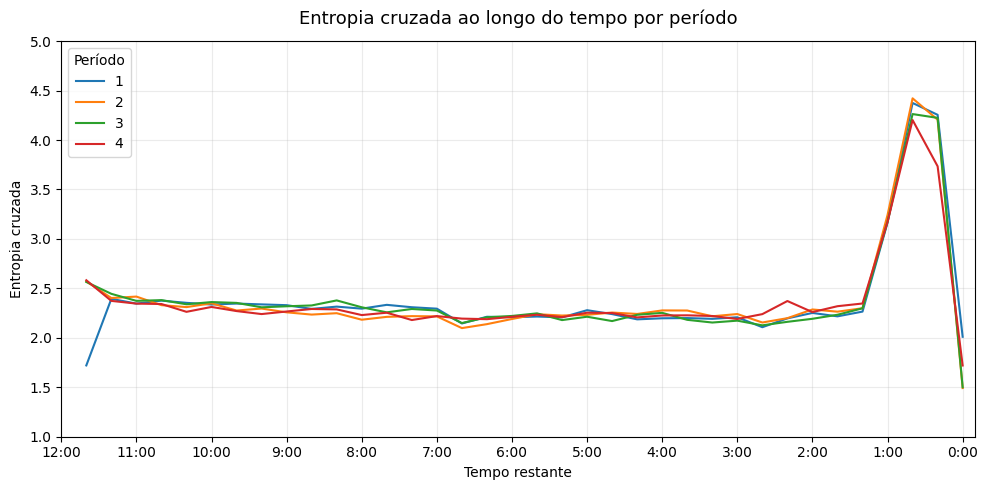

In [34]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 1")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "cross_entropy_mean")\
.plot(ax = ax)

ax.set_ylim(1, 5)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Entropia cruzada ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Entropia cruzada")
#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



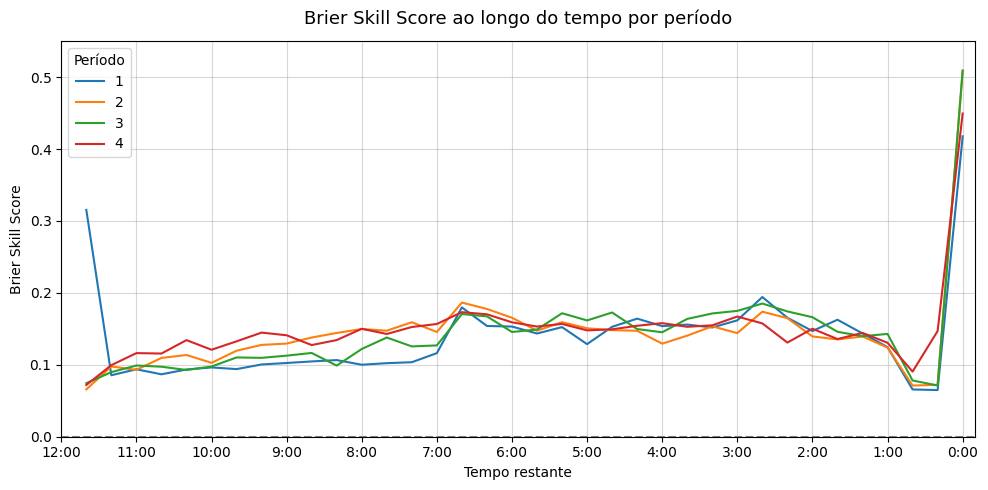

In [35]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 1")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bss_mean")\
.plot(ax = ax)

ax.set_ylim(0, 0.55)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.5)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Skill Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Skill Score")
ax.axhline(0, zorder = -3, linestyle = '--', color = 'gray')
plt.tight_layout()



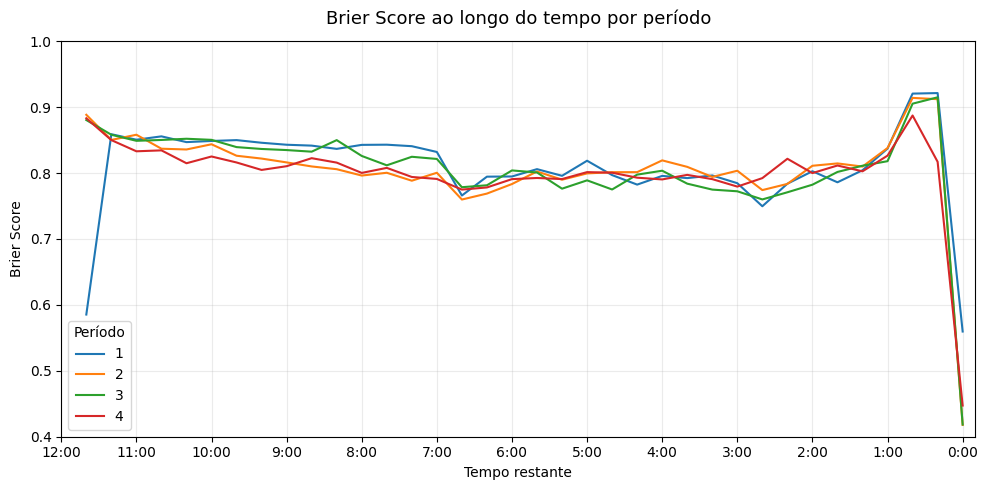

In [36]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 1")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bs_mean")\
.plot(ax = ax)

ax.set_ylim(0.4, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Score")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



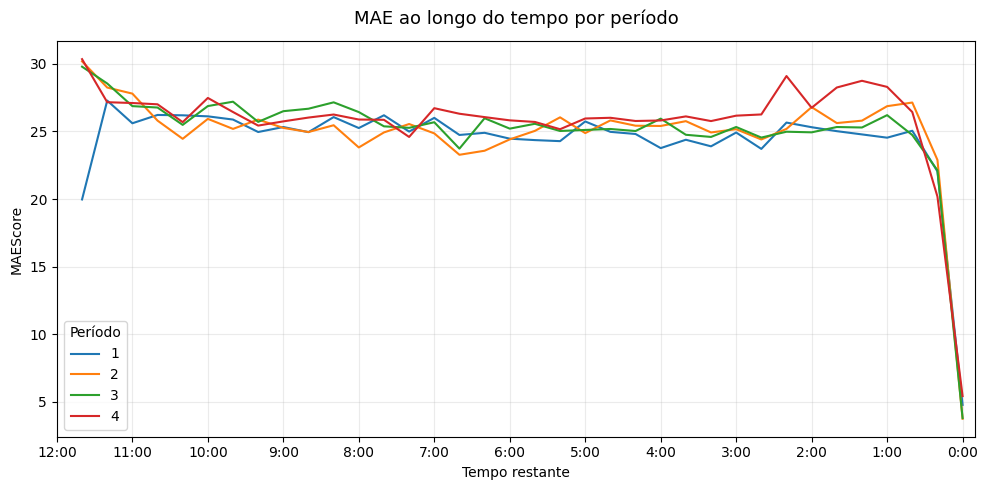

In [37]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 1")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "mae_mean")\
.plot(ax = ax)

#ax.set_ylim(0.4, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("MAE ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("MAEScore")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



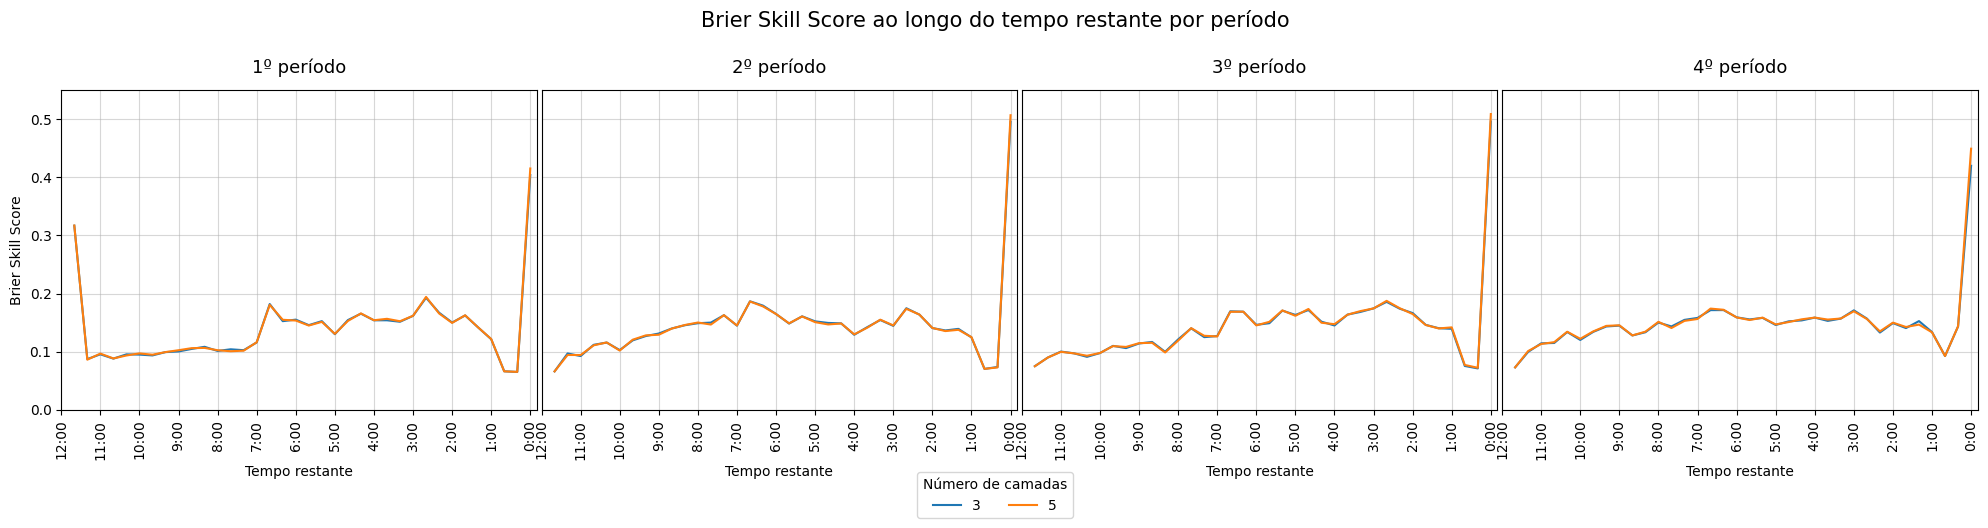

In [38]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "num_layers", values = "bss_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(0, 0.55)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Brier Skill Score ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Número de camadas",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

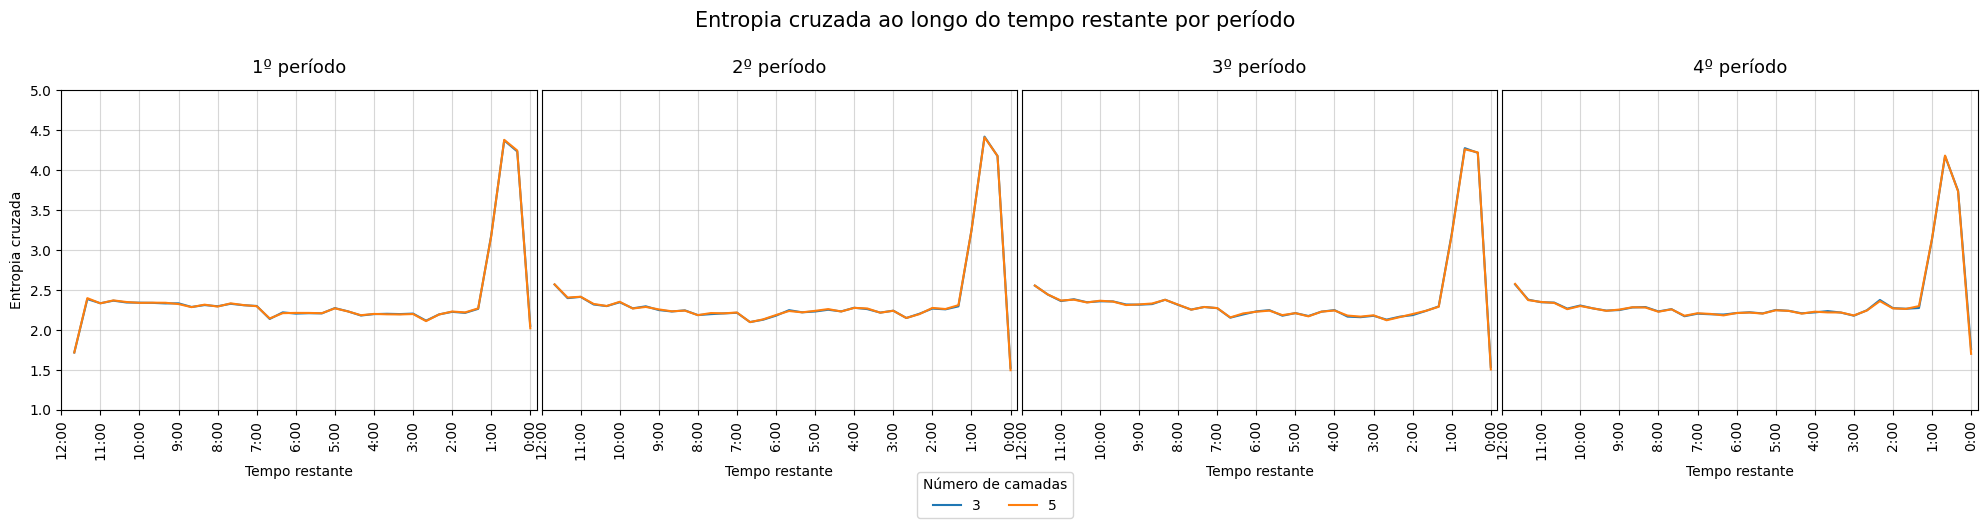

In [39]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "num_layers", values = "cross_entropy_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(1, 5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Entropia cruzada ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Número de camadas",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

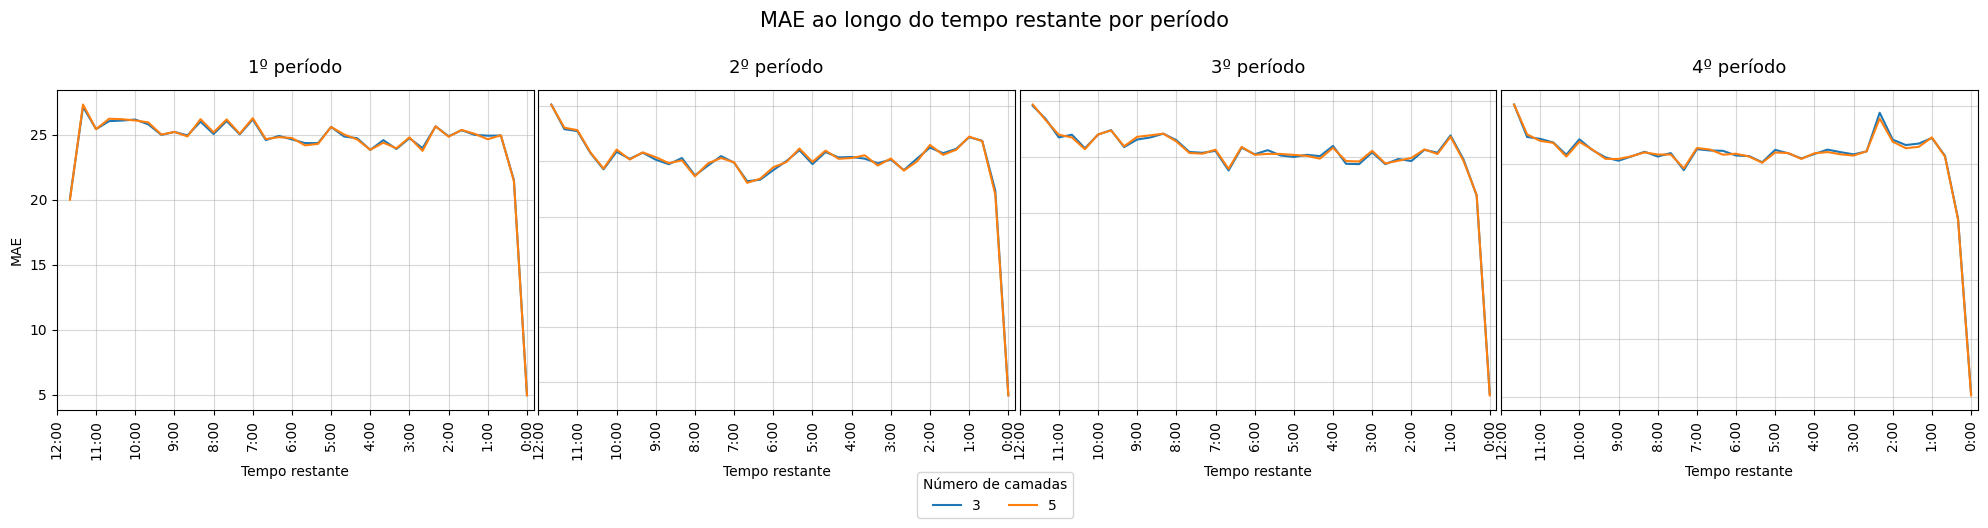

In [40]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "num_layers", values = "mae_mean")\
    .plot(ax = ax[i], legend=False)

#    ax[i].set_ylim(1, 5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("MAE")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("MAE ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Número de camadas",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

In [41]:
df_resultados3.query("cat_time in ['0-200'] & period == 4")\
.pivot_table(index = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"], columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,period,cat_time,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,4,0-200,5,32,1,50,3,0.0,False,0.434277,0.427491,0.415279,0.389518,0.422432
1,4,0-200,5,32,1,50,3,0.0,True,0.397083,0.387010,0.370983,0.379286,0.386571
2,4,0-200,5,32,1,50,3,0.3,False,0.416713,0.417824,0.406327,0.398192,0.412132
3,4,0-200,5,32,1,50,3,0.3,True,0.393296,0.394023,0.372654,0.361780,0.383244
4,4,0-200,5,32,1,50,5,0.0,False,0.473481,0.451732,0.439956,0.424511,0.457639
5,4,0-200,5,32,1,50,5,0.0,True,0.408497,0.405137,0.367709,0.363869,0.392059
6,4,0-200,5,32,1,50,5,0.3,False,0.445716,0.428208,0.400393,0.404440,0.431046
7,4,0-200,5,32,1,50,5,0.3,True,0.389686,0.361491,0.365961,0.350725,0.376139
8,4,0-200,5,32,2,50,3,0.0,False,0.441671,0.425521,0.411420,0.397037,0.422245
9,4,0-200,5,32,2,50,3,0.0,True,0.396349,0.389367,0.373332,0.365949,0.375389


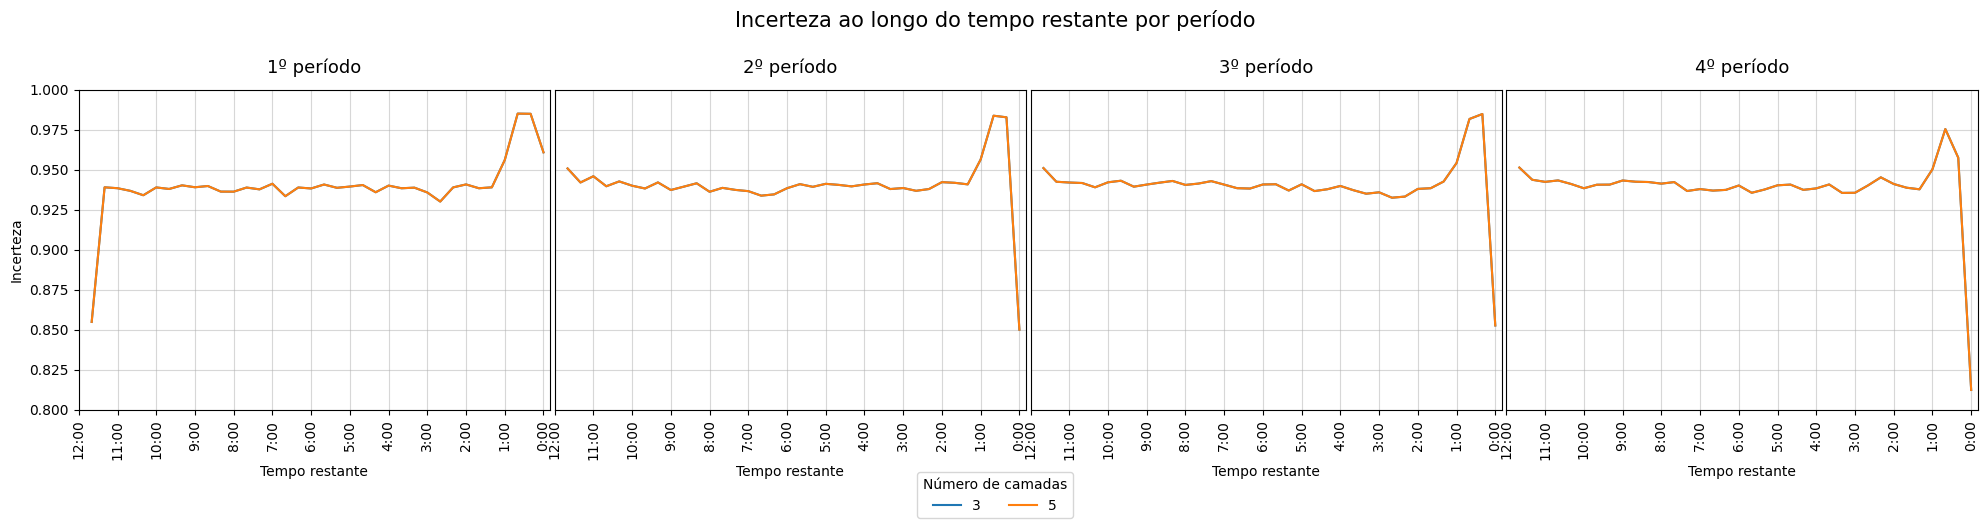

In [42]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "num_layers", values = "uncertainty_caos_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(0.8, 1)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Incerteza")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Incerteza ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Número de camadas",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

### Arquitetura B fine-tuning

In [14]:
list_decomposition_time = []
list_decomposition_dif = []
list_decomposition_time_dif = []
list_decomposition_season = []

group_variables1 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables2 = ["cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables3 = ["period", "cat_time", "cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables4 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_first46m" in item and ".pth" in item and str_season in item]

    df_ = df_time_features.query("season == @season").query("season_split == 'dev'")

    # Processamento temporal feito uma única vez por temporada
    df_ = (df_
            .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))
            .pipe(get_match_splits, num_secs = 200))\
    .assign(cat_time = lambda df: df["cat_time"].astype("str"))\
    .assign(cat_dif = lambda df: df["token_state"] % 9)

    # Conversão eficiente de memória
    dev_tkn1 = torch.from_numpy(np.stack(df_.query("ind_last_2_minutes_game == 0")["token_features"].values)).to(torch.int64)
    dev_num1 = torch.from_numpy(np.stack(df_.query("ind_last_2_minutes_game == 0")["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    dev_y1 = df_.query("ind_last_2_minutes_game == 0")["target_time"].values
    dev_mask1 = torch.tensor(build_logit_mask_spent_time_models(df_.query("ind_last_2_minutes_game == 0")), dtype = torch.bool, device = device)

    dev_tkn2 = torch.from_numpy(np.stack(df_.query("ind_last_2_minutes_game == 1")["token_features"].values)).to(torch.int64)
    dev_num2 = torch.from_numpy(np.stack(df_.query("ind_last_2_minutes_game == 1")["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    dev_y2 = df_.query("ind_last_2_minutes_game == 1")["target_time"].values
    dev_mask2 = torch.tensor(build_logit_mask_spent_time_models(df_.query("ind_last_2_minutes_game == 1")), dtype = torch.bool, device = device)

    mask_last2 = df_["ind_last_2_minutes_game"].to_numpy() == 1
    mask_first46 = ~mask_last2
    
    print(season)
    for model_filename in tqdm.tqdm(list_models):

        CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
        EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
        variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
        numerical_input_size = len(dict_set_covariables['index'][variables_config])
        num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
        num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
        dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
        layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

        index_covariables = dict_set_covariables["index"][variables_config]

        time_model_first46m = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE, 
                                             embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = numerical_input_size,
                                             num_hidden_neurons = num_hidden_neurons, num_layers = num_layers, 
                                             activation_function = nn.GELU, dropout_rate = dropout_rate, use_layer_norm = layer_norm)
    
        time_model_first46m.load_state_dict(torch.load(models_time_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
        time_model_first46m.eval()

        time_model_last2m = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE, 
                                             embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = numerical_input_size,
                                             num_hidden_neurons = num_hidden_neurons, num_layers = num_layers, 
                                             activation_function = nn.GELU, dropout_rate = dropout_rate, use_layer_norm = layer_norm)
    
        time_model_last2m.load_state_dict(torch.load(models_time_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
        time_model_last2m.eval()

        model_filename = model_filename.replace("first46m", "last2m")
        time_model_last2m.load_state_dict(torch.load(models_time_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
        time_model_last2m.eval()

        # 2. INFERÊNCIA
        with torch.no_grad():
            # Ajuste condicional para modelos que requerem variáveis numéricas
            output_model1 = time_model_first46m(dev_tkn1[:, -CONTEXT_SIZE:], dev_num1[:, index_covariables])
            output_model2 = time_model_last2m(dev_tkn2[:, -CONTEXT_SIZE:], dev_num2[:, index_covariables])

            output_model1 = output_model1.masked_fill(dev_mask1, -1e9)
            output_model2 = output_model2.masked_fill(dev_mask2, -1e9)

            all_probs1 = torch.softmax(output_model1, dim = 1).cpu().numpy()
            all_probs2 = torch.softmax(output_model2, dim = 1).cpu().numpy()
            
        #all_probs = np.concat([all_probs1, all_probs2])
        all_probs = np.empty((len(df_), TIME_SIZE), dtype = np.float32)
        all_probs[mask_first46] = all_probs1
        all_probs[mask_last2] = all_probs2
        dev_y = df_["target_time"].to_numpy()
        #dev_y = np.concat([dev_y1, dev_y2])
       
        # 3. EXTRAÇÃO POR TEMPO
        results_time = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            results_time.append(res_df)

        df_decomposition_by_time = pd.concat(results_time, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time = df_decomposition_by_time\
        .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time.append(df_resultados_time)

        # 3. EXTRAÇÃO POR DIF
        results_dif = []
        for name, group_idx in df_.groupby(["season_split", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["cat_dif"] = name[1]
            results_dif.append(res_df)

        df_decomposition_by_dif = pd.concat(results_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_dif = df_decomposition_by_dif\
        .groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_dif[group_variables2 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_dif.append(df_resultados_dif)

        # 3. EXTRAÇÃO POR TIME E DIF
        results_time_dif = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            res_df["cat_dif"] = name[3]
            results_time_dif.append(res_df)

        df_decomposition_by_time_dif = pd.concat(results_time_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time_dif = df_decomposition_by_time_dif\
        .groupby(group_variables3 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time_dif[group_variables3 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time_dif.append(df_resultados_time_dif)

        # 4. EXTRAÇÃO POR SPLIT
        results_split = []
        for name, group_idx in df_.groupby(["season_split"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
            res_df["season_split"] = name
            results_split.append(res_df)
            
        df_decomposition_by_split = pd.concat(results_split, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_split = df_decomposition_by_split\
        .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_split[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_season.append(df_resultados_split)


2018-19


100%|██████████| 32/32 [04:33<00:00,  8.55s/it]


2019-20


100%|██████████| 32/32 [04:08<00:00,  7.76s/it]


2020-21


100%|██████████| 32/32 [04:04<00:00,  7.63s/it]


2021-22


100%|██████████| 32/32 [04:30<00:00,  8.46s/it]


2022-23


100%|██████████| 32/32 [04:20<00:00,  8.15s/it]


In [15]:
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo_segregated\\"


In [16]:
df_murphy_decomposition_by_time = pd.concat(list_decomposition_time, ignore_index = True)
df_murphy_decomposition_by_time.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TIME_MODEL.parquet", index = False, compression = "zstd")


In [17]:
df_murphy_decomposition_by_dif = pd.concat(list_decomposition_dif, ignore_index = True)
df_murphy_decomposition_by_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_dif_TIME_MODEL.parquet", index = False, compression = "zstd")

In [18]:
df_murphy_decomposition_by_time_dif = pd.concat(list_decomposition_time_dif, ignore_index = True)
df_murphy_decomposition_by_time_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_dif_TIME_MODEL.parquet", index = False, compression = "zstd")

In [19]:


df_murphy_decomposition_by_season_split = pd.concat(list_decomposition_season, ignore_index = True)
df_murphy_decomposition_by_season_split.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TIME_MODEL.parquet", index = False, compression = "zstd")


In [16]:
list_num_parametros1 = []
list_num_parametros2 = []
for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_first46m" in item and ".pkl" in item and str_season in item]

    for file in tqdm.tqdm(list_models):
        with open(models_time_folder + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros1.append((file.replace("results_", ""), resultados_modelo["num_parameters"]))

    list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_last2m" in item and ".pkl" in item and str_season in item]
    for file in tqdm.tqdm(list_models):
        with open(models_time_folder + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros2.append((file.replace("results_", ""), resultados_modelo["num_parameters"]))



  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [00:00<00:00, 41.54it/s]


In [17]:
df_parameters = pd.DataFrame(list_num_parametros2, columns = ["modelname", "num_parameters"])

In [18]:
df_parameters\
.assign(seasondata = lambda df: df["modelname"].str.split("_").str[2].str.replace("seasondata", "").astype("int"))\
.assign(context_size = lambda df: df["modelname"].str.split("_").str[3].str.replace("context", "").astype("int"))\
.assign(embedding_layer_size = lambda df: df["modelname"].str.split("_").str[4].str.replace("embedding", "").astype("int"))\
.assign(num_layers = lambda df: df["modelname"].str.split("_").str[5].str.replace("numlayers", "").astype("int"))\
.assign(num_hidden_neurons = lambda df: df["modelname"].str.split("_").str[6].str.replace("numneurons", "").astype("int"))\
.assign(dropout_rate = lambda df: df["modelname"].str.split("_").str[7].str.replace("dropout", "").replace("no", 0).astype("int") / 10)\
.assign(layer_norm = lambda df: df["modelname"].str.split("_").str[8].str.replace("layernorm", ""))\
.assign(set_covariables = lambda df: df["modelname"].str.split("_").str[9].str.replace("setcovariables", "").replace("\.pkl", "", regex = True).astype("int"))\
.drop(columns = "modelname")\
.sort_values("num_parameters")\
.drop_duplicates(["context_size", "embedding_layer_size", "num_layers", "num_hidden_neurons", "layer_norm", "set_covariables"])\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "set_covariables"], columns = ["num_layers", "layer_norm"], values = "num_parameters", aggfunc= lambda x: x)\
.reset_index()

num_layers context_size embedding_layer_size num_hidden_neurons  \
layer_norm                                                        
0                     5                   32                 50   
1                     5                   32                 50   
2                     5                   64                 50   
3                     5                   64                 50   

num_layers set_covariables      3             5         
layer_norm                  False   True  False   True  
0                        1  48533  49085  53633  54385  
1                        2  49733  50333  54833  55633  
2                        1  75765  76637  80865  81937  
3                        2  76965  77885  82065  83185

In [19]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TIME_MODEL.parquet")

In [20]:
group_variables1 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [21]:
df_resultados1 = df_murphy_decomposition_by_season_split\
.groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_season_split[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

df_resultados2 = df_resultados1\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [22]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   2.3743 (0.0219) [1]  2.3847 (0.0231) [21]   
1                          2   2.3754 (0.0223) [3]  2.3817 (0.0218) [11]   
2                          1   2.3770 (0.0231) [4]   2.3817 (0.0211) [9]   
3                          2   2.3749 (0.0223) [2]  2.3827 (0.0202) [15]   
4                          1   2.3794 (0.0211) [6]  2.3850 (0.0233) [23]   
5                          2   2.3780 (0.0207) [5]  2.3849 (0.0226) [22]   
6                          1  2.3817 (0.0213) [10]  2.3851 (0.0230) [24]   
7                          2   2.3797 (0.0230) [8]  2.3843 (0.0223) [19]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.3846 (0.0229) [20]  2.3833 (0.0231) [17]  
1             2.3822 (0.0203) [13]  2.3823 (0.0243) [14]  
2             2.3971 (0.0218) [31]  2.3973 (0.0226) [32]  
3             2.3962 (0.0208) [29]  2.3931 (0.0219) [25]  
4             2.3831 (0.0217) [16]  2.3841 (0.0236) [18]  
5              2.3797 (0.0207) [7]  2.3822 (0.0215) [12]  
6             2.3966 (0.0219) [30]  2.3960 (0.0230) [28]  
7             2.3954 (0.0202) [27]  2.3948 (0.0216) [26]

In [23]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   0.1623 (0.0041) [3]  0.1607 (0.0045) [19]   
1                          2   0.1620 (0.0045) [4]  0.1610 (0.0042) [14]   
2                          1   0.1624 (0.0043) [2]  0.1609 (0.0041) [16]   
3                          2   0.1626 (0.0042) [1]  0.1609 (0.0041) [17]   
4                          1  0.1613 (0.0043) [11]  0.1606 (0.0043) [22]   
5                          2   0.1615 (0.0039) [5]  0.1605 (0.0044) [23]   
6                          1   0.1614 (0.0042) [6]  0.1603 (0.0045) [24]   
7                          2   0.1614 (0.0047) [7]  0.1606 (0.0043) [21]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.1606 (0.0043) [20]  0.1613 (0.0042) [13]  
1             0.1607 (0.0038) [18]  0.1613 (0.0045) [10]  
2             0.1589 (0.0040) [29]  0.1594 (0.0043) [28]  
3             0.1588 (0.0038) [32]  0.1598 (0.0042) [26]  
4             0.1610 (0.0042) [15]  0.1613 (0.0043) [12]  
5              0.1614 (0.0041) [8]   0.1613 (0.0041) [9]  
6             0.1589 (0.0041) [30]  0.1599 (0.0045) [25]  
7             0.1588 (0.0037) [31]  0.1595 (0.0042) [27]

In [24]:
df_resultados2\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   24.479 (0.3457) [5]  24.552 (0.3888) [14]   
1                          2   24.449 (0.3600) [3]  24.526 (0.3806) [10]   
2                          1   24.508 (0.3752) [7]  24.563 (0.3676) [16]   
3                          2   24.447 (0.3521) [2]  24.627 (0.4046) [23]   
4                          1  24.538 (0.3615) [12]  24.625 (0.4158) [22]   
5                          2   24.441 (0.3477) [1]  24.538 (0.3506) [13]   
6                          1   24.509 (0.3792) [8]  24.598 (0.3839) [20]   
7                          2  24.559 (0.3918) [15]  24.597 (0.2935) [19]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             24.744 (0.3737) [29]   24.511 (0.3419) [9]  
1             24.665 (0.3619) [24]   24.485 (0.3361) [6]  
2             24.861 (0.3732) [32]  24.678 (0.3537) [25]  
3             24.756 (0.3600) [30]  24.586 (0.3401) [18]  
4             24.731 (0.3533) [27]  24.535 (0.3711) [11]  
5             24.614 (0.3342) [21]   24.478 (0.3658) [4]  
6             24.851 (0.3558) [31]  24.688 (0.3441) [26]  
7             24.741 (0.3307) [28]  24.586 (0.3674) [17]

In [25]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["layer_norm", "dropout_rate"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	16.0	15.4375	10.295428	1.0	7.75	14.5	22.0	32.0
# 1	64	16.0	17.5625	 8.571027	5.0	9.50	18.5	24.5	30.0

# num_layers
# 0	3	16.0	13.0625	 7.037696	1.0	6.75	13.5	18.50	23.0
# 1	5	16.0	19.9375	10.350322	2.0	9.75	24.5	28.25	32.0

# set_covariables
# 0	1	16.0	18.125	9.871677	1.0	9.75	19.0	25.00	32.0
# 1	2	16.0	14.875	8.875998	2.0	7.75	13.5	22.75	29.0

# dropout_rate
# 0	0.0	16.0	11.4375	8.082646	1.0	 4.75	 9.5	19.50	24.0
# 1	0.3	16.0	21.5625	7.865272	7.0	15.50	22.5	28.25	32.0

# layer_norm
# 0	False	16.0	13.25	10.804320	1.0	 4.75	 9.0	21.75	31.0
# 1	True	16.0	19.75	 6.526868	9.0	14.75	20.0	24.25	32.0

# layer_norm, dropout_rate
# 0	False	0.0	8.0	 4.875	3.044316	 1.0	 2.75	 4.5	 6.50	10.0
# 1	False	0.3	8.0	21.625	8.975164	 7.0	15.25	23.5	29.25	31.0
# 2	True	0.0	8.0	18.000	5.682052	 9.0	14.00	20.0	22.25	24.0
# 3	True	0.3	8.0	21.500	7.211103	12.0	16.25	21.5	26.50	32.0


,layer_norm,dropout_rate,count,mean,std,min,25%,50%,75%,max
0,False,0.0,8.0,4.875,3.044316,1.0,2.75,4.5,6.50,10.0
1,False,0.3,8.0,21.625,8.975164,7.0,15.25,23.5,29.25,31.0
2,True,0.0,8.0,18.000,5.682052,9.0,14.00,20.0,22.25,24.0
3,True,0.3,8.0,21.500,7.211103,12.0,16.25,21.5,26.50,32.0


In [26]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["embedding_layer_size"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	16.0	15.75	9.936465	1.0	8.50	16.5	21.50	32.0
# 1	64	16.0	17.25	9.051703	5.0	8.75	18.0	24.25	31.0

# num_layers
# 0	3	16.0	12.875	 6.302116	3.0	 8.75	12.5	18.25	23.0
# 1	5	16.0	20.125	10.682540	1.0	13.75	24.5	28.25	32.0

# set_covariables
# 0	1	16.0	17.1875	 8.975662	2.0	11.75	17.5	24.25	30.0
# 1	2	16.0	15.8125	10.014781	1.0	 7.75	15.5	23.75	32.0

#dropout_rate
# 0	0.0	16.0	12.1875	8.231798	1.0	 4.75	12.5	19.50	24.0
# 1	0.3	16.0	20.8125	8.627234	8.0	12.75	22.5	28.25	32.0

# layer_norm
# 0	False	16.0	13.875	11.312972	1.0	 4.75	 9.5	22.25	32.0
# 1	True	16.0	19.125	 6.259659	9.0	13.75	20.0	24.25	28.0

# layer_norm, dropout_rate
# 0	False	0.0	8.0	4.875	3.181981	 1.0	 2.75	 4.5	 6.25	11.0
# 1	False	0.3	8.0	22.875	8.887190	 8.0	17.25	24.5	30.25	32.0
# 2	True	0.0	8.0	19.500	3.585686	14.0	16.75	20.0	22.25	24.0
# 3	True	0.3	8.0	18.750	8.413425	 9.0	11.50	19.0	26.25	28.0




,embedding_layer_size,count,mean,std,min,25%,50%,75%,max
0,32,16.0,15.75,9.936465,1.0,8.50,16.5,21.50,32.0
1,64,16.0,17.25,9.051703,5.0,8.75,18.0,24.25,31.0


In [27]:
df_resultados1\
.pivot_table(index = group_variables1, columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,5,32,1,50,3,0.0,False,0.158093,0.161403,0.159277,0.164870,0.168279
1,5,32,1,50,3,0.0,True,0.155830,0.159814,0.157388,0.163455,0.167043
2,5,32,1,50,3,0.3,False,0.155799,0.159639,0.157890,0.163108,0.166825
3,5,32,1,50,3,0.3,True,0.156776,0.160166,0.158577,0.163463,0.167633
4,5,32,1,50,5,0.0,False,0.157747,0.161574,0.159571,0.164666,0.168754
5,5,32,1,50,5,0.0,True,0.156272,0.160976,0.157916,0.163100,0.166720
6,5,32,1,50,5,0.3,False,0.154315,0.157906,0.156446,0.161811,0.164393
7,5,32,1,50,5,0.3,True,0.155319,0.157329,0.157025,0.161336,0.166101
8,5,32,2,50,3,0.0,False,0.157465,0.161198,0.158662,0.164520,0.168528
9,5,32,2,50,3,0.0,True,0.156757,0.160002,0.157951,0.163457,0.167152


In [28]:
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TIME_MODEL.parquet")

In [29]:
group_variables2 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [30]:
df_resultados3 = df_murphy_decomposition_by_time\
.groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_time[group_variables2 + ["seasondata", "brier_score_multinomial", "cross_entropy", "mae"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

In [31]:
df_resultados4 = df_resultados3\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

In [32]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   1.7631 (0.0586) [5]  1.8545 (0.0796) [21]   
1                          2   1.7593 (0.0654) [4]  1.8572 (0.0678) [22]   
2                          1   1.7181 (0.0652) [2]  1.8488 (0.0696) [19]   
3                          2   1.7109 (0.0774) [1]  1.8605 (0.0766) [23]   
4                          1  1.7930 (0.0677) [16]  1.8635 (0.0509) [24]   
5                          2  1.7812 (0.0685) [11]  1.8680 (0.0680) [26]   
6                          1   1.7708 (0.0557) [8]  1.8722 (0.0596) [27]   
7                          2   1.7708 (0.0624) [9]  1.8512 (0.0538) [20]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             1.7927 (0.0549) [14]  1.8674 (0.0695) [25]  
1              1.7646 (0.0600) [7]  1.8451 (0.0578) [18]  
2             1.7913 (0.0770) [13]  1.9155 (0.0563) [32]  
3              1.7643 (0.0841) [6]  1.8745 (0.0699) [28]  
4             1.7827 (0.0737) [12]  1.8759 (0.0547) [29]  
5              1.7556 (0.0624) [3]  1.8433 (0.0564) [17]  
6             1.7928 (0.0795) [15]  1.8886 (0.0807) [31]  
7             1.7747 (0.0654) [10]  1.8792 (0.0705) [30]

In [33]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1  0.4197 (0.0163) [11]  0.3794 (0.0155) [25]   
1                          2   0.4202 (0.0163) [9]  0.3796 (0.0146) [24]   
2                          1   0.4486 (0.0162) [1]  0.3852 (0.0176) [20]   
3                          2   0.4441 (0.0197) [2]  0.3791 (0.0136) [26]   
4                          1  0.4040 (0.0145) [16]  0.3785 (0.0128) [29]   
5                          2  0.4094 (0.0170) [15]  0.3789 (0.0148) [28]   
6                          1  0.4184 (0.0145) [12]  0.3779 (0.0093) [30]   
7                          2  0.4111 (0.0171) [14]  0.3839 (0.0133) [21]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.4163 (0.0100) [13]  0.3858 (0.0144) [19]  
1             0.4202 (0.0143) [10]  0.3864 (0.0101) [18]  
2              0.4275 (0.0182) [4]  0.3730 (0.0151) [32]  
3              0.4293 (0.0235) [3]  0.3791 (0.0142) [27]  
4              0.4220 (0.0184) [8]  0.3836 (0.0125) [22]  
5              0.4231 (0.0147) [7]  0.3879 (0.0152) [17]  
6              0.4273 (0.0263) [5]  0.3830 (0.0158) [23]  
7              0.4248 (0.0217) [6]  0.3750 (0.0140) [31]

In [34]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  5.4399 (0.4630) [6]  5.6344 (0.5934) [10]   
1                          2  5.2173 (0.6317) [2]  5.6691 (0.4979) [11]   
2                          1  5.3414 (0.4986) [3]  5.7701 (0.3767) [18]   
3                          2  5.1859 (0.5019) [1]  5.8403 (0.5033) [20]   
4                          1  5.5248 (0.5628) [8]  5.7527 (0.3169) [17]   
5                          2  5.3955 (0.5503) [5]  5.7463 (0.4956) [16]   
6                          1  5.3931 (0.4291) [4]  5.9399 (0.5756) [24]   
7                          2  5.4847 (0.4058) [7]  5.7391 (0.4569) [15]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             6.6169 (0.5666) [30]  6.3353 (0.5790) [25]  
1             5.7060 (0.4932) [13]  5.6992 (0.4461) [12]  
2             6.7972 (0.6538) [31]  6.5246 (0.5111) [28]  
3             5.9243 (0.5650) [23]  5.8378 (0.4846) [19]  
4             6.5495 (0.5637) [29]  6.4641 (0.5604) [27]  
5              5.6000 (0.4376) [9]  5.7076 (0.4366) [14]  
6             6.8344 (0.6160) [32]  6.4137 (0.5909) [26]  
7             5.8702 (0.5159) [22]  5.8552 (0.4655) [21]

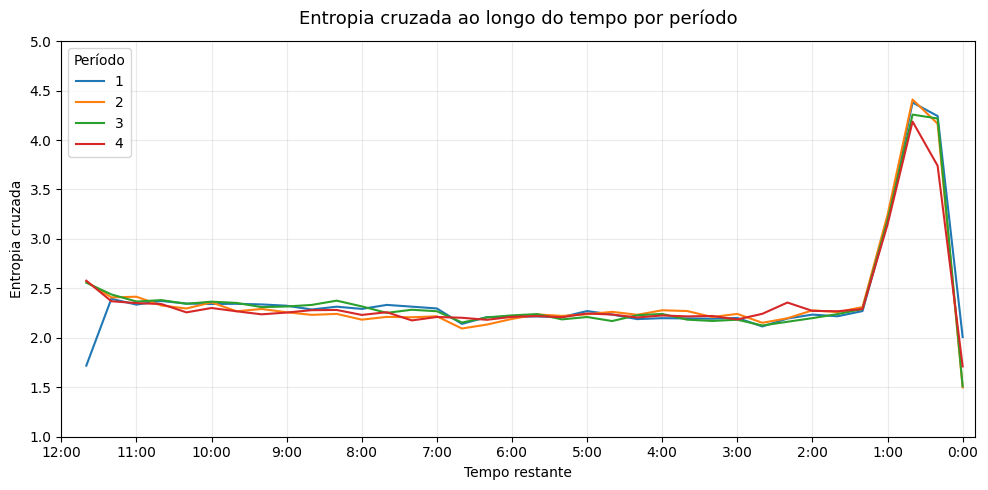

In [35]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "cross_entropy_mean")\
.plot(ax = ax)

ax.set_ylim(1, 5)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Entropia cruzada ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Entropia cruzada")
#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



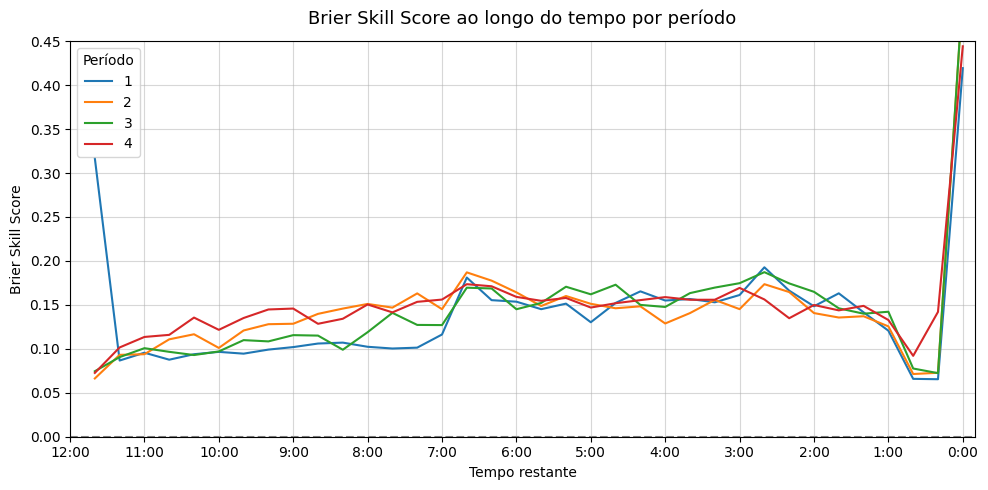

In [36]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bss_mean")\
.plot(ax = ax)

ax.set_ylim(0, 0.45)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.5)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Skill Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Skill Score")
ax.axhline(0, zorder = -3, linestyle = '--', color = 'gray')
plt.tight_layout()



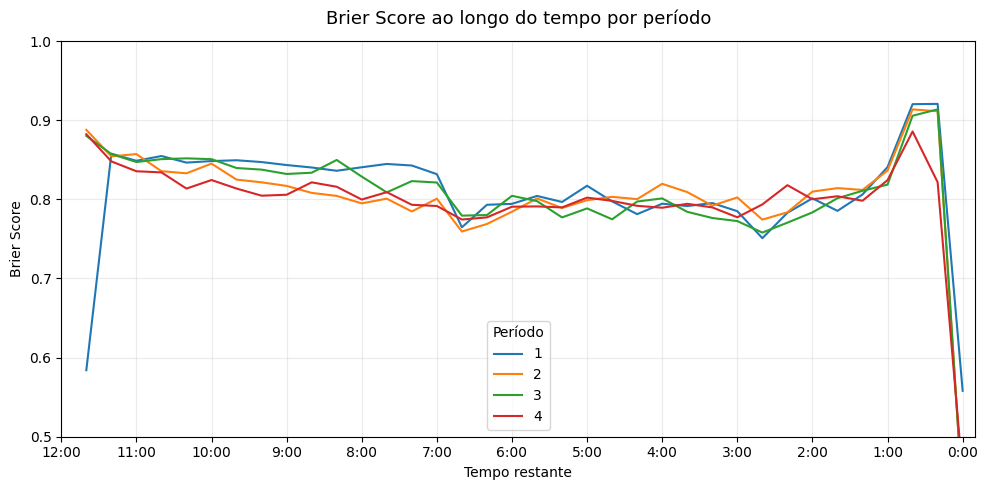

In [37]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bs_mean")\
.plot(ax = ax)

ax.set_ylim(0.5, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Score")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



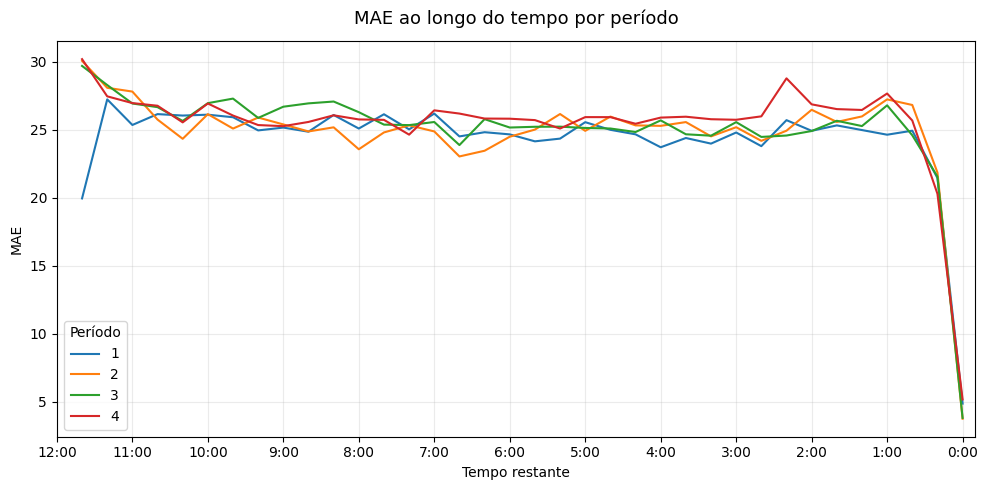

In [38]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "mae_mean")\
.plot(ax = ax)

#ax.set_ylim(0.5, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("MAE ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("MAE")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



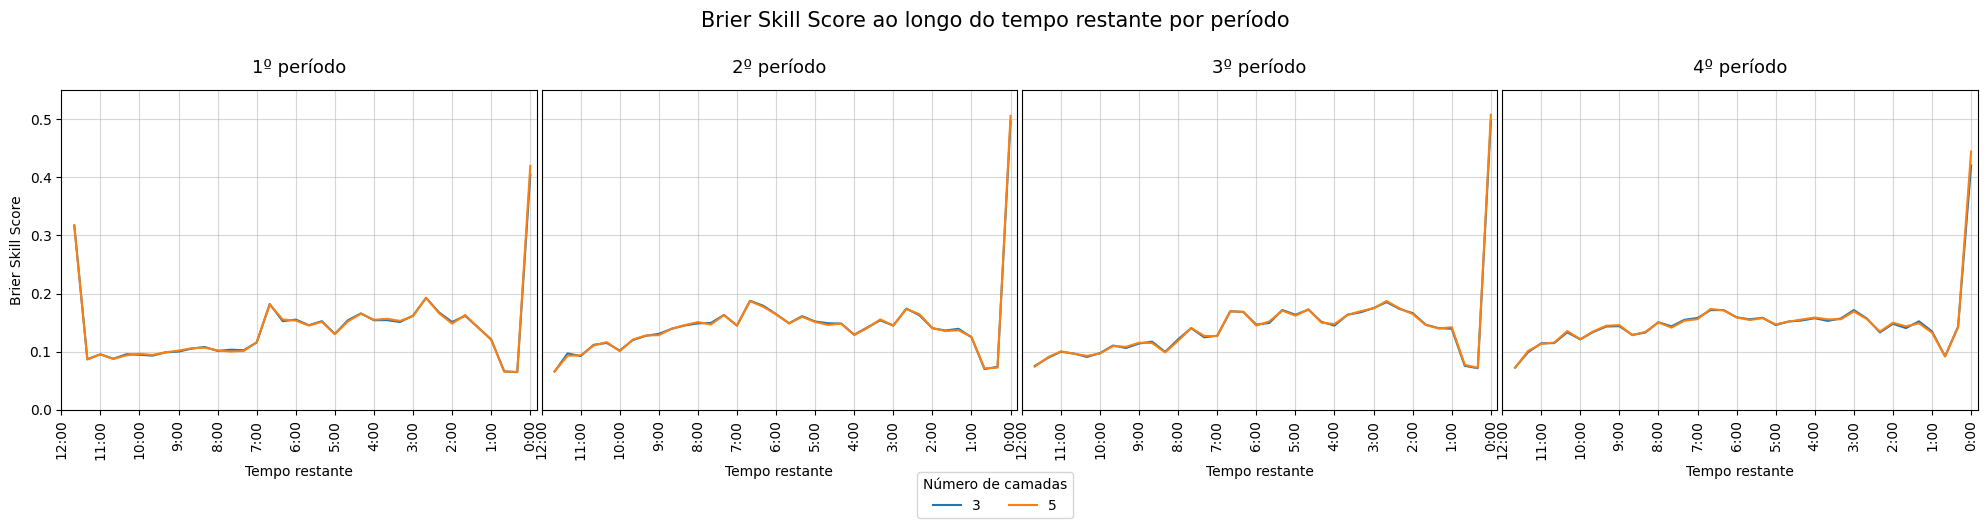

In [39]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "num_layers", values = "bss_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(0, 0.55)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Brier Skill Score ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Número de camadas",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

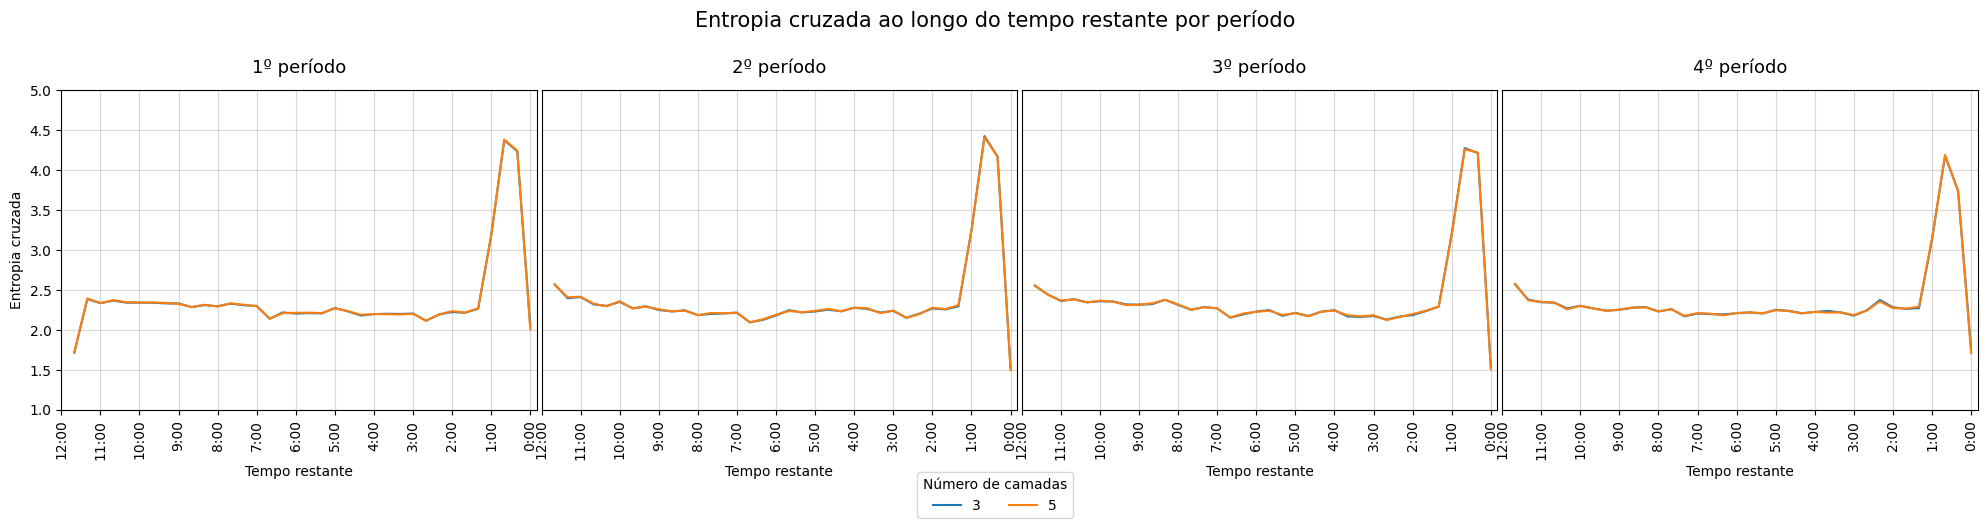

In [40]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "num_layers", values = "cross_entropy_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(1.0, 5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Entropia cruzada ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Número de camadas",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

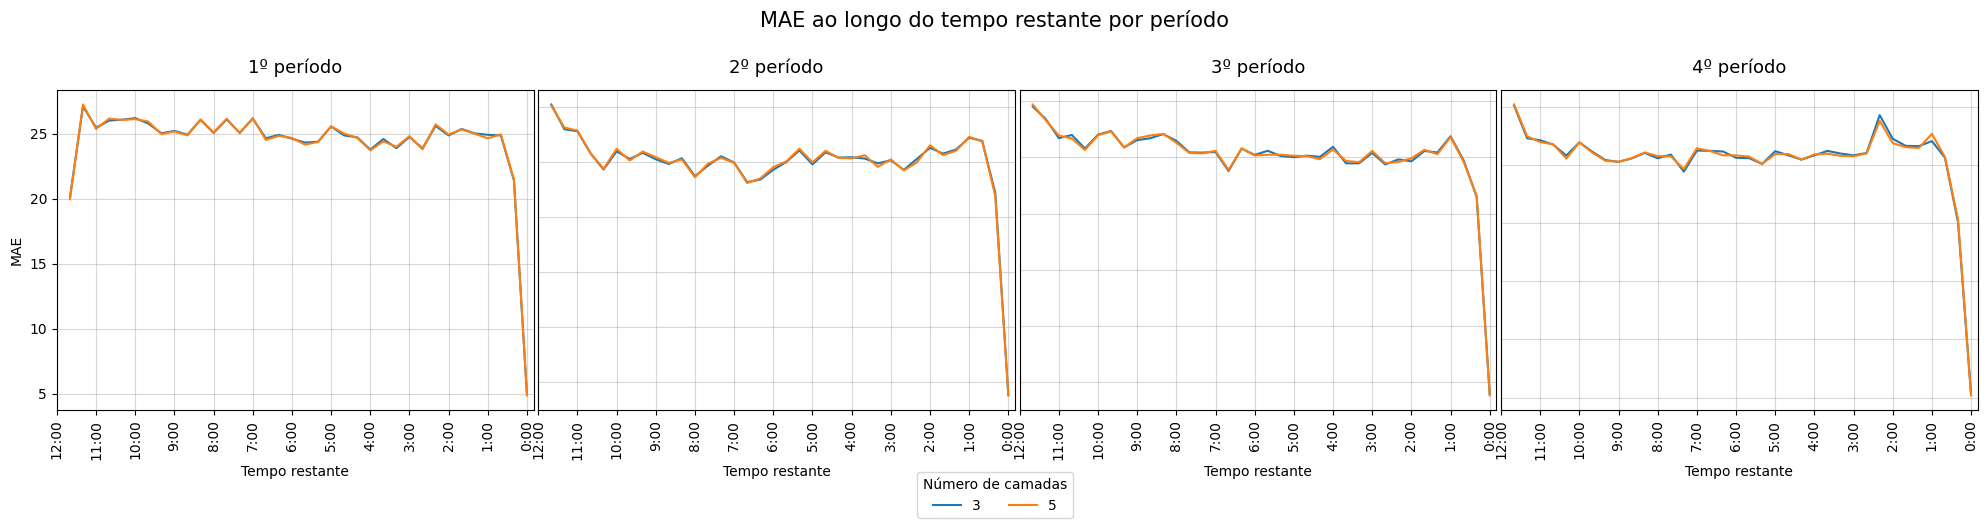

In [41]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "num_layers", values = "mae_mean")\
    .plot(ax = ax[i], legend=False)

#    ax[i].set_ylim(1.0, 5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("MAE")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("MAE ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Número de camadas",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

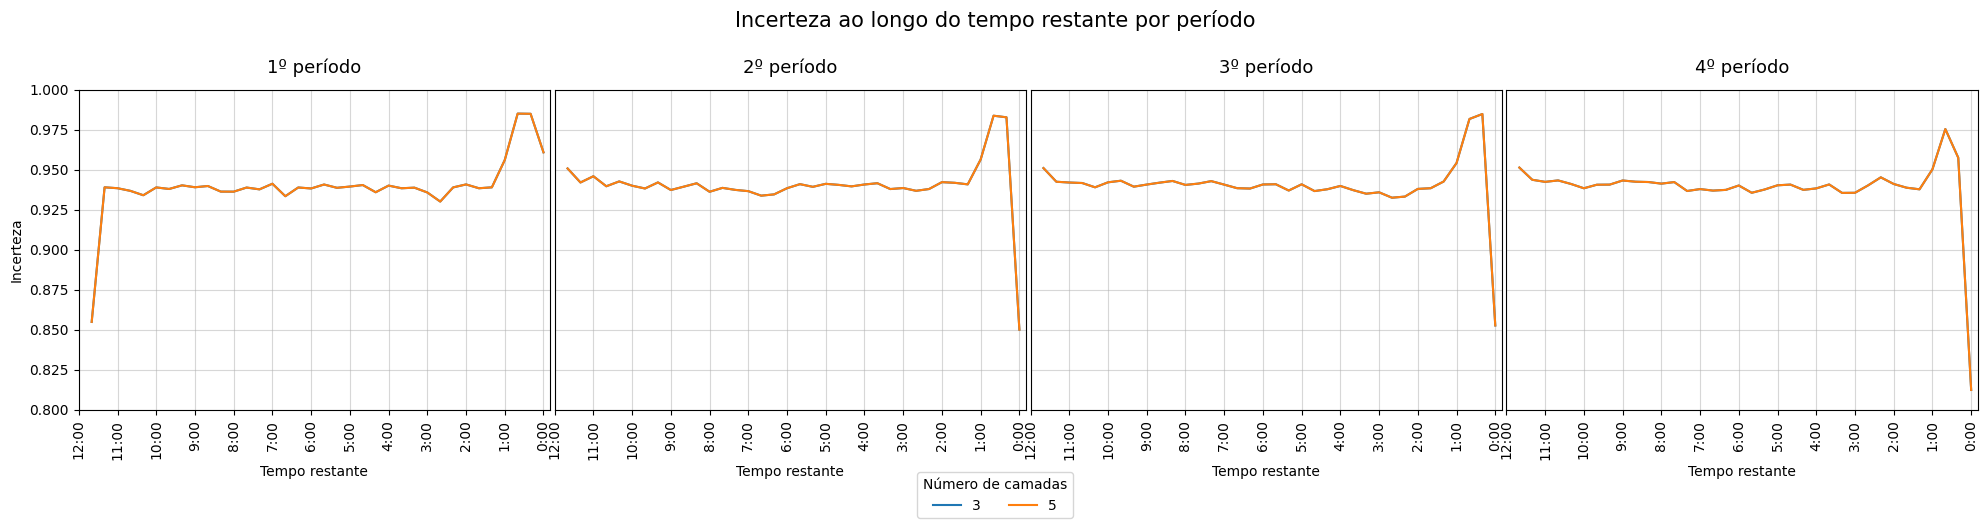

In [42]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "num_layers", values = "uncertainty_caos_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(0.8, 1)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Incerteza")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Incerteza ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Número de camadas",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

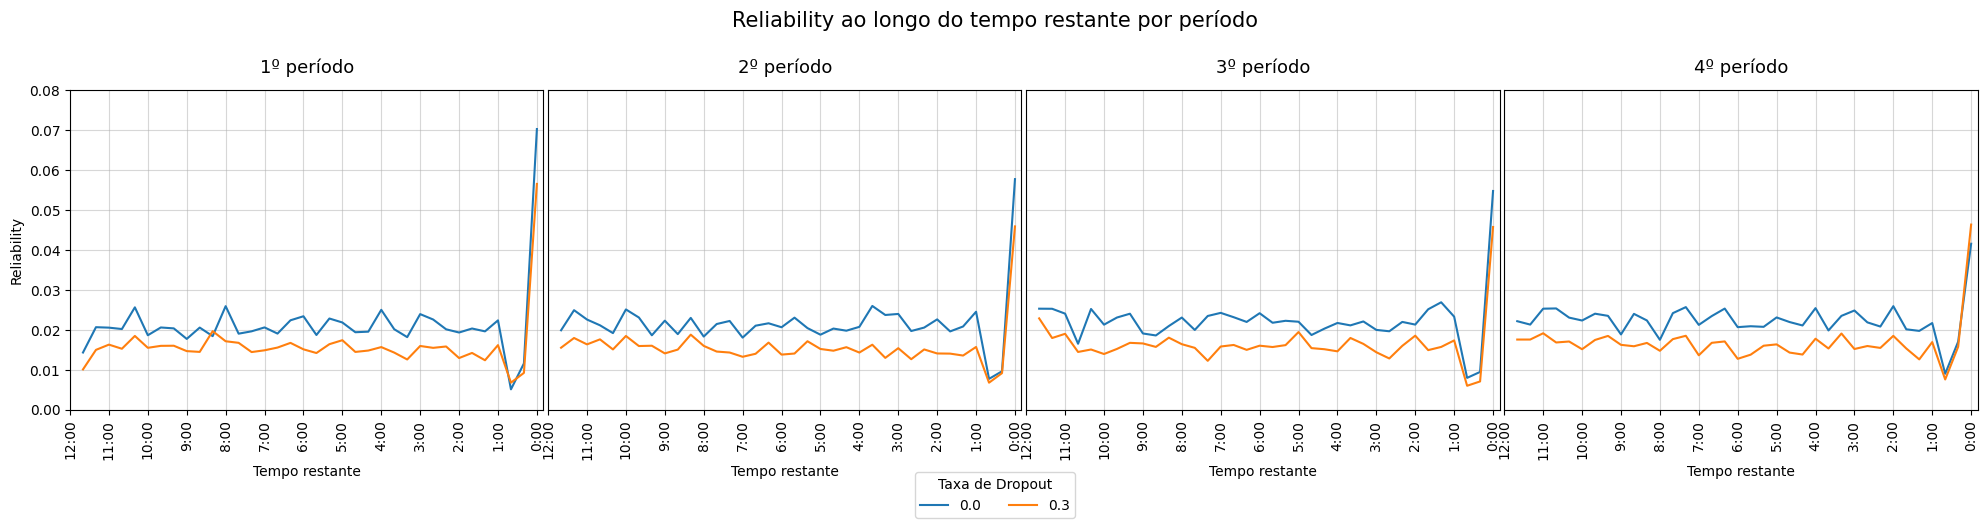

In [43]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "reliability_erro_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(0.0, 0.08)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Reliability")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Reliability ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa de Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

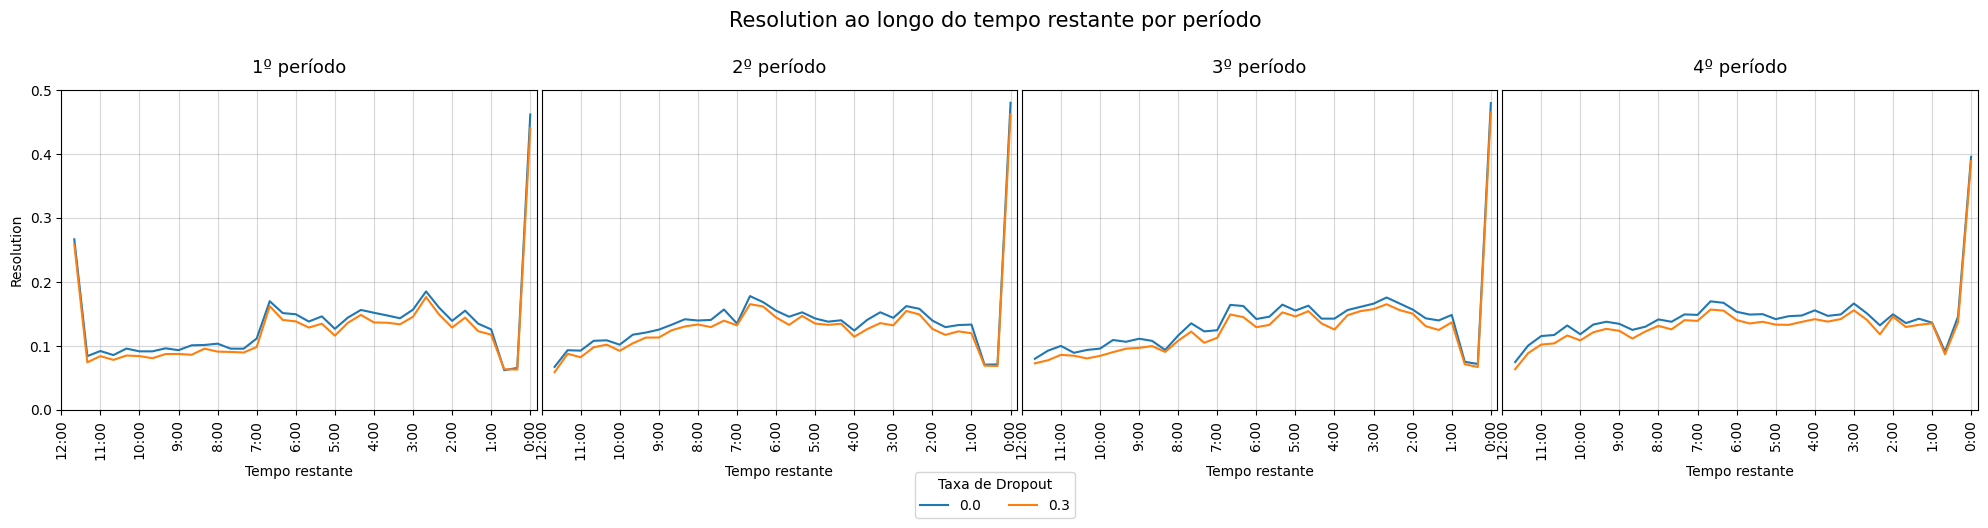

In [44]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "resolution_poder_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(0.0, 0.5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Resolution")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Resolution ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa de Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()